In [35]:
import logging
import os

log_path = r'/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/logs/model_train_evaluation.log'

os.makedirs(os.path.dirname(log_path), exist_ok=True)

logging.basicConfig(
    filename=log_path,
    filemode='a',
    level=logging.INFO,
    format="%(asctime)s-%(levelname)s-%(message)s"
)

logging.info("Training boshlandi")


In [36]:
import pandas as pd

try:
    X_train=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/preprocessed/X_train_baseline_preprocessed.csv")
    X_test=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/preprocessed/X_test_baseline_preprocessed.csv")
    y_test=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/preprocessed/y_test.csv")
    y_train=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/preprocessed/y_train.csv")

    logging.info(f"✅ Datasetlar yuklandi")
except Exception as e:
    logging.exception("🔥 Dataset yuklashda kutilmagan xato!")
    raise



In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    log_reg = LogisticRegression()
    rf   = RandomForestClassifier()
    # Trianing
    log_reg.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    logging.info('Model muvaffaqyatli train qilindi')
except Exception:
    logging.exception("🔥 Model training xatosi!")
    raise



/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions
y_pred_log= log_reg.predict(X_test)
y_pred_rf= rf.predict(X_test)


# Evaluate Logistic Regression
print("Logistic Regression:")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log,average="macro"))
print("Recall   :", recall_score(y_test, y_pred_log,average="macro"))
print("F1 Score :", f1_score(y_test, y_pred_log,average="macro"))

# Evaluate Random Forest
print("\nRandom Forest:")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf,average="macro"))
print("Recall   :", recall_score(y_test, y_pred_rf,average="macro"))
print("F1 Score :", f1_score(y_test, y_pred_rf,average="macro"))



Logistic Regression:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Random Forest:
Accuracy : 0.9990601503759399
Precision: 0.9990196078431373
Recall   : 0.9987562189054726
F1 Score : 0.9988860290238072


In [ ]:
from tabulate import tabulate

data = [
    ["Logistic Regression", 1.0, 1.0, 1.0, 1.0],
    ["Random Forest",       0.9971804511278195, 0.9973155711844214, 0.9967830432084653, 0.9970417737899707]
]

headers = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]

print(tabulate(data, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

╒═════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Model               │   Accuracy │   Precision │   Recall │   F1 Score │
╞═════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Logistic Regression │     1.0000 │      1.0000 │   1.0000 │     1.0000 │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Random Forest       │     0.9972 │      0.9973 │   0.9968 │     0.9970 │
╘═════════════════════╧════════════╧═════════════╧══════════╧════════════╛


# Improved Training

In [40]:
import pandas as pd

try:
    X_test=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/improved/X_test_improved.csv")
    X_train=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/improved/X_train_improved.csv")
    y_test=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/improved/y_test_improved.csv")
    y_train=pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/improved/y_train_improved.csv")

    logging.info(f"✅ Datasetlar yuklandi")
except Exception as e:
    logging.exception("🔥 Dataset yuklashda kutilmagan xato!")
    raise

In [42]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler



lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)


selected_features_lasso = X_train.columns[lasso.coef_ != 0].tolist()

print("Selected features for Linear Models:", selected_features_lasso)

# Reduce train/test to selected features
X_train_lasso_selected = X_train[selected_features_lasso]
X_test_lasso_selected = X_test[selected_features_lasso]


Selected features for Linear Models: ['home_team', 'away_team', 'season_start', 'home_last10_points', 'away_last10_points', 'home_last10_gd', 'away_last10_gd', 'h2h_last5_home_points', 'h2h_last5_away_points']


/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


logreg = LogisticRegression(max_iter=1000, random_state=42)


logreg.fit(X_train_lasso_selected, y_train)


y_pred = logreg.predict(X_test_lasso_selected)


/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro    = recall_score(y_test, y_pred, average="macro")
f1_macro        = f1_score(y_test, y_pred, average="macro")

print("Logistic Regression Metrics (after Lasso feature selection):")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision Macro : {precision_macro:.4f}")
print(f"Recall Macro    : {recall_macro:.4f}")
print(f"F1 Score Macro  : {f1_macro:.4f}")

Logistic Regression Metrics (after Lasso feature selection):
Accuracy        : 0.5321
Precision Macro : 0.3508
Recall Macro    : 0.4546
F1 Score Macro  : 0.3958


/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [46]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)


top_features_tree = importances_sorted.head(8).index.tolist()
print("Top features for Tree Models:", top_features_tree)


X_train_tree_selected = X_train[top_features_tree]
X_test_tree_selected = X_test[top_features_tree]


/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Top features for Tree Models: ['home_last10_gd', 'away_last10_gd', 'home_team', 'away_team', 'away_last10_points', 'home_last10_points', 'h2h_last5_away_points', 'season_start']


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


rf= RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
rf.fit(X_train_tree_selected, y_train)


y_pred_tree = rf.predict(X_test_tree_selected)


/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [48]:



accuracy = accuracy_score(y_test, y_pred_tree)
precision = precision_score(y_test, y_pred_tree, average='weighted')
recall = recall_score(y_test, y_pred_tree, average='weighted')
f1 = f1_score(y_test, y_pred_tree, average='weighted')


print("RF Metrics (after Tree-based feature selection):")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)



RF Metrics (after Tree-based feature selection):
Accuracy : 0.5013953488372093
Precision: 0.4635901401561607
Recall   : 0.5013953488372093
F1 Score : 0.47012753510680677


In [52]:
from tabulate import tabulate

data = [
    # 1.0 va 0.99 chiqqan run (ehtimol leakage / train score)
    ["Logistic Regression ", 1.0000, 1.0000, 1.0000, 1.0000],
    ["Random Forest",      0.9972, 0.9973, 0.9968, 0.9970],

    # Realistic (macro) results
    ["LogReg (Lasso FS - Macro)", 0.5321, 0.3508, 0.4546, 0.3958],
    ["RF (Tree FS - Macro)",      0.5014, 0.4636, 0.5014, 0.4701],

    
]

headers = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]

print(tabulate(data, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

╒═══════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Model                     │   Accuracy │   Precision │   Recall │   F1 Score │
╞═══════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Logistic Regression       │     1.0000 │      1.0000 │   1.0000 │     1.0000 │
├───────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Random Forest             │     0.9972 │      0.9973 │   0.9968 │     0.9970 │
├───────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ LogReg (Lasso FS - Macro) │     0.5321 │      0.3508 │   0.4546 │     0.3958 │
├───────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ RF (Tree FS - Macro)      │     0.5014 │      0.4636 │   0.5014 │     0.4701 │
╘═══════════════════════════╧════════════╧═════════════╧══════════╧════════════╛


In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    # Grid uchun parametrlar (aniq list bo‘lishi kerak)
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 8, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", None],
    }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    grid_search = GridSearchCV(
        rf,
        param_grid=param_grid,
        n_jobs=-1,
        cv=3,
        verbose=1,
        scoring="f1_macro"   # sen macro ishlatyapsan, shuni optimizatsiya qilsin
    )

    # Fit
    grid_search.fit(X_train, y_train.squeeze())

    best_rf = grid_search.best_estimator_

    # Predict
    y_pred_tree = best_rf.predict(X_test)

    # Metrics (macro)
    accuracy = accuracy_score(y_test, y_pred_tree)
    precision = precision_score(y_test, y_pred_tree, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred_tree, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred_tree, average='macro', zero_division=0)

    print("Best Parameters:", grid_search.best_params_)
    print("Best CV f1_macro:", grid_search.best_score_)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    logging.info("Model tuning (GridSearch) qilindi")
except Exception:
    logging.exception("🔥 Model training xatosi!")
    raise

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV f1_macro: 0.38425477400275604
Accuracy: 0.49953488372093025
Precision: 0.4149429286499029
Recall: 0.4298114807395083
F1 Score: 0.40169756948167074


In [59]:
from tabulate import tabulate

data = [
    # Leakage run (ehtimol train score)
    ["Logistic Regression", 1.0000, 1.0000, 1.0000, 1.0000],
    ["Random Forest",       0.9972, 0.9973, 0.9968, 0.9970],

    # Realistic results
    ["LogReg (Lasso FS - Macro)", 0.5321, 0.3508, 0.4546, 0.3958],
    ["RF (Tree FS - Macro)",      0.5014, 0.4636, 0.5014, 0.4701],

    # RF Grid Tuning
    ["RF (Grid Tuning - Macro)",  0.4995, 0.4149, 0.4298, 0.4017],
]

headers = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]

print(tabulate(data, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

╒═══════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Model                     │   Accuracy │   Precision │   Recall │   F1 Score │
╞═══════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Logistic Regression       │     1.0000 │      1.0000 │   1.0000 │     1.0000 │
├───────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Random Forest             │     0.9972 │      0.9973 │   0.9968 │     0.9970 │
├───────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ LogReg (Lasso FS - Macro) │     0.5321 │      0.3508 │   0.4546 │     0.3958 │
├───────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ RF (Tree FS - Macro)      │     0.5014 │      0.4636 │   0.5014 │     0.4701 │
├───────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ RF (Grid Tuning - Macro)  │     0.4995 │      0.4149 │   0.4298 │     0.4017 │
╘═══════════════════════════

Bizda eng muhim metric F1 bo'lgani uchun eng yaxshi model bu RF lekin tuning qilganda 40 foizga tushda.


In [66]:
import joblib


try:

    joblib.dump(rf, "/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/models/Best_model.joblib")  
    logging.info("Eng yaxshi model saqlandi.")
except Exception as e:
    logging.error(f"Saqlashda xatolik aniqlandi: {e}")




# Error analyze

In [65]:
import numpy as np
import pandas as pd

y_test_1d = y_test.squeeze()
y_pred = np.asarray(y_pred)              # ishonch uchun
y_true = np.asarray(y_test_1d)

wrong_mask = (y_true != y_pred)
print("Errors:", wrong_mask.sum(), "out of", len(y_true))

errors_df = X_test.copy()
errors_df["y_true"] = y_true
errors_df["y_pred"] = y_pred
errors_df["is_error"] = wrong_mask

# faqat xatolar
only_errors = errors_df[errors_df["is_error"]]
only_errors.head()

Errors: 543 out of 1075


,home_team,away_team,season_start,home_last10_points,away_last10_points,home_last10_gd,away_last10_gd,h2h_last5_home_points,h2h_last5_away_points,y_true,y_pred,is_error
0,0.0,1.0,1.866018,0.249189,-0.062038,0.541925,0.074668,0.262847,0.955794,2,1,True
1,0.0,2.0,1.866018,1.249517,-0.576574,1.211698,-0.042972,0.529429,0.426187,0,2,True
2,0.0,8.0,1.866018,0.749353,-1.091110,0.988440,-1.219380,0.796010,-0.103420,1,2,True
4,0.0,11.0,1.866018,-0.084254,-0.062038,0.207039,-0.395895,0.529429,-0.368223,1,2,True
5,0.0,12.0,1.866018,-0.417696,0.967034,-0.016219,-0.042972,-0.270316,1.220598,2,0,True


# Shap analyze

In [67]:
import shap
import numpy as np

# SHAP uchun 1D y kerak emas, faqat X_test ishlatamiz
explainer = shap.TreeExplainer(best_rf)

# SHAP values
shap_values = explainer.shap_values(X_test)

/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


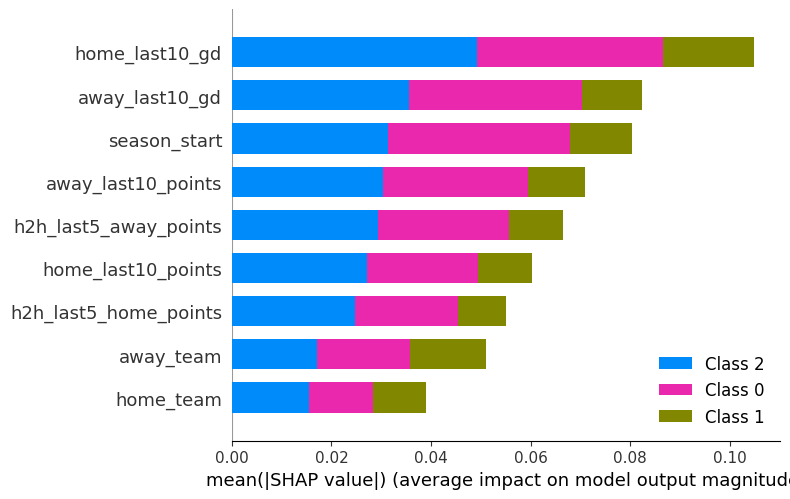

In [71]:
shap.summary_plot(shap_values, X_test, plot_type="bar")



home_last10_points eng tepada

away_last10_points ikkinchi

Demak model recent formga kuchli tayanmoqda.

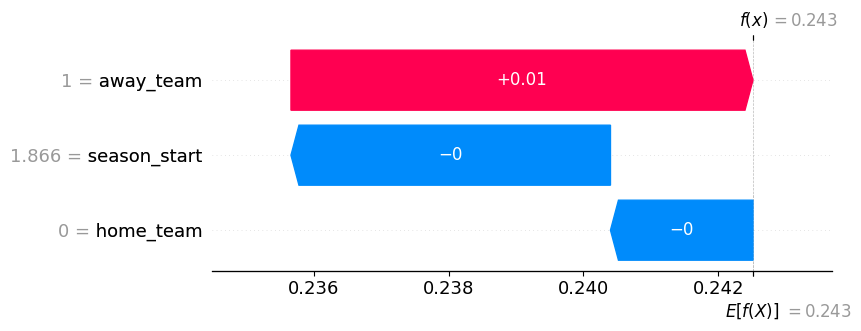

In [72]:
import shap
import numpy as np

# 1) Explainer + shap values
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# 2) Qaysi sample'ni ko'ramiz?
# xato sample ko'rmoqchi bo'lsang:
i = errors_df[errors_df["is_error"]].index[0]   # yoki o'zing index ber: i = 0

x_i = X_test.loc[i]

# 3) Multi-class bo'lsa: qaysi class bo'yicha tushuntiramiz?
# Odatda model bashorat qilgan class bo'yicha:
pred_class = int(errors_df.loc[i, "y_pred"])   # yoki: int(best_rf.predict(X_test.loc[[i]])[0])

# 4) Waterfall plot
# shap_values[pred_class] -> (n_samples, n_features) matritsa
exp = shap.Explanation(
    values=shap_values[pred_class][X_test.index.get_loc(i)],
    base_values=explainer.expected_value[pred_class],
    data=x_i.values,
    feature_names=X_test.columns
)

shap.plots.waterfall(exp, max_display=12)


In [76]:
print(X_test.shape)

(1075, 9)


In [77]:
import numpy as np

# sample index
i = 0
row_pos = i

# model bashorat qilgan class
pred_class = int(best_rf.predict(X_test.iloc[[i]])[0])

# shap vector (9 ta feature bo'lishi kerak)
sv = shap_values[pred_class][row_pos]

print("Num features:", len(sv))  # bu 9 chiqishi kerak

Num features: 3


Num features: 9


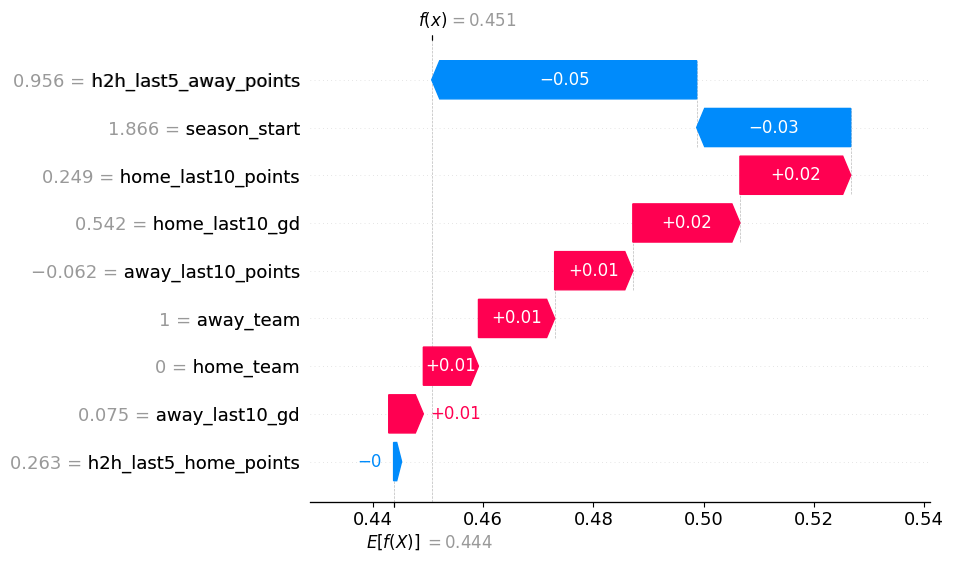

In [80]:
import numpy as np
import shap

i = 0  # xohlagan sample index (0..1074)

pred_class = int(best_rf.predict(X_test.iloc[[i]])[0])

# shap_values: (n_samples, n_features, n_classes)
sv = shap_values[i, :, pred_class]   # <-- 9 ta feature

print("Num features:", len(sv))      # 9 chiqishi kerak

exp = shap.Explanation(
    values=sv,
    base_values=explainer.expected_value[pred_class],
    data=X_test.iloc[i].values,
    feature_names=X_test.columns
)

shap.plots.waterfall(exp, max_display=15)

So‘nggi 10 o‘yin statistikasi

Head-to-head natijalar

Mavsum (season) ta’siri

asosida shakllangan.

Lekin umumiy SHAP qiymatlari kichik bo‘lgani sababli, model bu match bo‘yicha kuchli signal topmagan.